This notebook is used to generate helper figures to explain graph concepts, such as ego graphs.

## Ego Graph Visual

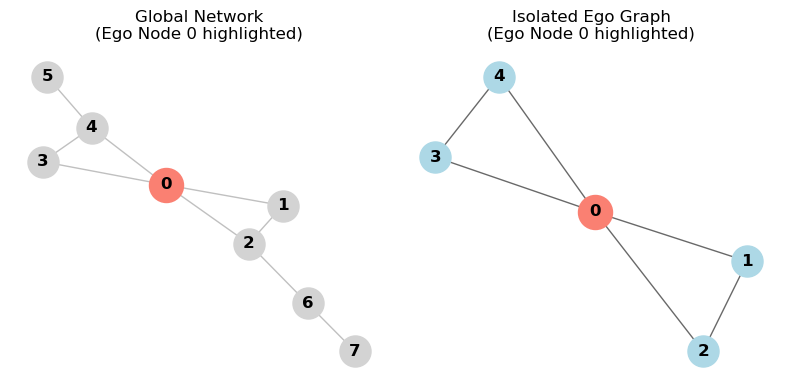

In [12]:
import networkx as nx
import matplotlib.pyplot as plt

# Generate a simple global graph
G = nx.Graph()
G.add_edges_from([
    (0, 1), (0, 2), (0, 3), (0, 4),  # Edges connected directly to the Ego
    (1, 2), (3, 4),                  # Edges between the alters
    (4, 5), (2, 6), (6, 7),  # Edges leading out into the broader network
])

# Define the focal node
ego_node = 0

# Extract the ego graph
ego_net = nx.ego_graph(G, ego_node)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

pos = nx.spring_layout(G, seed=42)

# Plot 1: Global Graph
nx.draw(G, pos, ax=ax1, with_labels=True, node_color='lightgray', 
        edge_color='silver', node_size=500, font_weight='bold')
nx.draw_networkx_nodes(G, pos, nodelist=[ego_node], 
                       node_color='salmon', node_size=600, ax=ax1)
ax1.set_title(f"Global Network\n(Ego Node {ego_node} highlighted)")

# Plot 2: Ego Graph
nx.draw(ego_net, pos, ax=ax2, with_labels=True, node_color='lightblue', 
        edge_color='dimgray', node_size=500, font_weight='bold')
nx.draw_networkx_nodes(ego_net, pos, nodelist=[ego_node], 
                       node_color='salmon', node_size=600, ax=ax2)
ax2.set_title(f"Isolated Ego Graph\n(Ego Node {ego_node} highlighted)")

plt.tight_layout()
plt.show()

## Assortativity Comparison

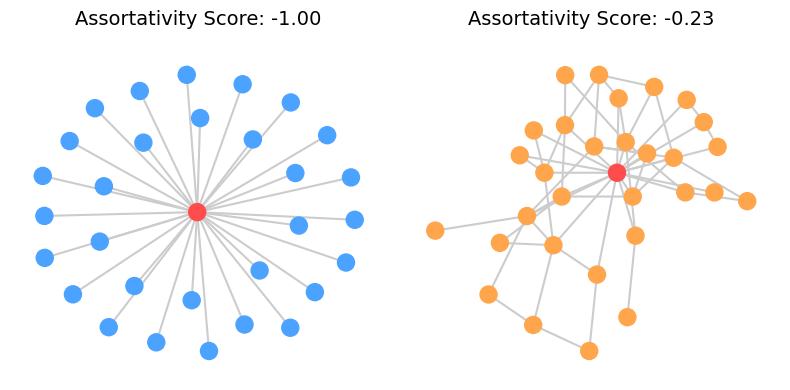

In [37]:
import networkx as nx
import matplotlib.pyplot as plt
import itertools
import random
random.seed(42)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

G_low = nx.star_graph(30)

# Calculate assortativity
assort_low = nx.degree_assortativity_coefficient(G_low)

# Low Assortativity Graph
pos_low = nx.spring_layout(G_low, seed=42)
node_colors_low = ['#ff4c4c' if node == 0 else '#4ca3ff' for node in G_low.nodes()]

nx.draw(G_low, pos_low, ax=axes[0], node_color=node_colors_low, 
        with_labels=False, node_size=150, edge_color='#cccccc', width=1.5)
axes[0].set_title(f"Assortativity Score: {assort_low:.2f}", fontsize=14, pad=15)


# High Assortativity Graph
G_high = nx.Graph()
ego = 0
hubs = list(range(1, 31))
G_high.add_node(ego)
for h in hubs:
    if random.random() < 0.6:  # Connect most hubs to the ego
        G_high.add_edge(ego, h)
# G_high.add_edges_from([(ego, h) for h in hubs])

# Randomly connect hubs to increase assortativity
for u, v in itertools.combinations(hubs, 2):
    if random.random() < 0.10:
        G_high.add_edge(u, v)

# Calculate assortativity
assort_high = nx.degree_assortativity_coefficient(G_high)

pos_high = nx.spring_layout(G_high, seed=42)
node_colors_high = ['#ff4c4c' if node == 0 else ('#ffa64c' if node in hubs else '#4ca3ff') for node in G_high.nodes()]

nx.draw(G_high, pos_high, ax=axes[1], node_color=node_colors_high, 
        with_labels=False, node_size=150, edge_color='#cccccc', width=1.5)
axes[1].set_title(f"Assortativity Score: {assort_high:.2f}", fontsize=14, pad=15)

# plt.suptitle("Assortativity as a Topological Structure", fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

## Random Forest Ensemble Classifier

C:\Users\malda\AppData\Local\Temp\ipykernel_75224\3506027466.py:109: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


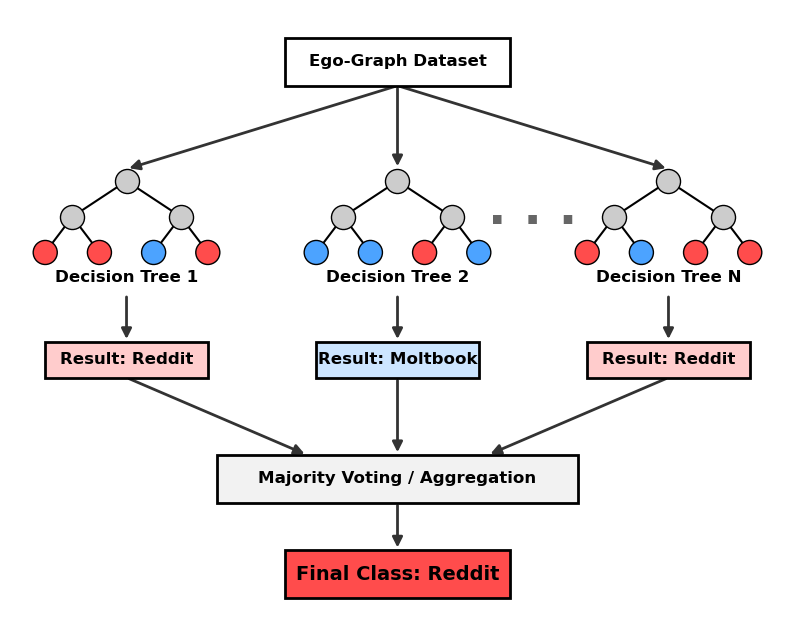

In [42]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Set up the figure
fig, ax = plt.subplots(figsize=(10, 8))
ax.axis('off')  # Turn off the standard plot axes

# ==========================================
# Helper Functions for Drawing Elements
# ==========================================
def draw_box(ax, x, y, width, height, text, fontsize=12, facecolor='#ffffff', edgecolor='black'):
    """Draws a clean, styled rectangle with centered text."""
    box = patches.Rectangle((x - width/2, y - height/2), width, height,
                            edgecolor=edgecolor, facecolor=facecolor, lw=2, zorder=2)
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center', fontsize=fontsize, fontweight='bold', zorder=3)

def draw_arrow(ax, x1, y1, x2, y2):
    """Draws a directed arrow between two coordinates."""
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='-|>', lw=2, color='#333333', mutation_scale=15), zorder=1)

def draw_decision_tree(ax, cx, cy, leaf_colors):
    """Draws a simplified mini decision tree (root, 2 branches, 4 leaves)."""
    dy = 0.06
    dx1 = 0.06
    dx2 = 0.03
    
    # Draw branches (lines)
    ax.plot([cx, cx-dx1], [cy, cy-dy], 'k-', lw=1.5, zorder=1)
    ax.plot([cx, cx+dx1], [cy, cy-dy], 'k-', lw=1.5, zorder=1)
    ax.plot([cx-dx1, cx-dx1-dx2], [cy-dy, cy-2*dy], 'k-', lw=1.5, zorder=1)
    ax.plot([cx-dx1, cx-dx1+dx2], [cy-dy, cy-2*dy], 'k-', lw=1.5, zorder=1)
    ax.plot([cx+dx1, cx+dx1-dx2], [cy-dy, cy-2*dy], 'k-', lw=1.5, zorder=1)
    ax.plot([cx+dx1, cx+dx1+dx2], [cy-dy, cy-2*dy], 'k-', lw=1.5, zorder=1)

    # Draw internal nodes (Gray)
    ix = [cx, cx-dx1, cx+dx1]
    iy = [cy, cy-dy, cy-dy]
    ax.scatter(ix, iy, s=300, c='#cccccc', edgecolors='black', zorder=4)

    # Draw leaf nodes (Colored by their specific prediction)
    lx = [cx-dx1-dx2, cx-dx1+dx2, cx+dx1-dx2, cx+dx1+dx2]
    ly = [cy-2*dy]*4
    ax.scatter(lx, ly, s=300, c=leaf_colors, edgecolors='black', zorder=4)

# ==========================================
# Constructing the Flowchart
# ==========================================

# 1. Top Level: Dataset Input
dataset_x, dataset_y = 0.5, 0.9
draw_box(ax, dataset_x, dataset_y, 0.25, 0.08, "Ego-Graph Dataset")

# 2. Middle Level: The Forest (Mini Trees)
tree_xs = [0.2, 0.5, 0.8]
tree_y = 0.7

# Color-coding leaves to represent classifications (Red = Reddit, Blue = Moltbook)
tree1_leaves = ['#ff4c4c', '#ff4c4c', '#4ca3ff', '#ff4c4c'] # Tree 1 leans Reddit
tree2_leaves = ['#4ca3ff', '#4ca3ff', '#ff4c4c', '#4ca3ff'] # Tree 2 leans Moltbook
tree3_leaves = ['#ff4c4c', '#4ca3ff', '#ff4c4c', '#ff4c4c'] # Tree N leans Reddit

draw_decision_tree(ax, tree_xs[0], tree_y, tree1_leaves)
draw_decision_tree(ax, tree_xs[1], tree_y, tree2_leaves)
draw_decision_tree(ax, tree_xs[2], tree_y, tree3_leaves)

# Add the Ellipsis to imply "N" amount of trees
ax.text(0.65, 0.65, ". . .", ha='center', va='center', fontsize=35, fontweight='bold', color='#666666')

# Tree Text Labels
ax.text(tree_xs[0], tree_y - 0.17, "Decision Tree 1", ha='center', fontsize=12, fontweight='bold')
ax.text(tree_xs[1], tree_y - 0.17, "Decision Tree 2", ha='center', fontsize=12, fontweight='bold')
ax.text(tree_xs[2], tree_y - 0.17, "Decision Tree N", ha='center', fontsize=12, fontweight='bold')

# Connect Dataset down to the Trees
draw_arrow(ax, dataset_x, dataset_y - 0.04, tree_xs[0], tree_y + 0.02)
draw_arrow(ax, dataset_x, dataset_y - 0.04, tree_xs[1], tree_y + 0.02)
draw_arrow(ax, dataset_x, dataset_y - 0.04, tree_xs[2], tree_y + 0.02)

# 3. Lower Level: Individual Results
result_y = 0.4
draw_box(ax, tree_xs[0], result_y, 0.18, 0.06, "Result: Reddit", facecolor='#ffcccc')
draw_box(ax, tree_xs[1], result_y, 0.18, 0.06, "Result: Moltbook", facecolor='#cce5ff')
draw_box(ax, tree_xs[2], result_y, 0.18, 0.06, "Result: Reddit", facecolor='#ffcccc')

# Connect Trees down to their Results
draw_arrow(ax, tree_xs[0], tree_y - 0.19, tree_xs[0], result_y + 0.03)
draw_arrow(ax, tree_xs[1], tree_y - 0.19, tree_xs[1], result_y + 0.03)
draw_arrow(ax, tree_xs[2], tree_y - 0.19, tree_xs[2], result_y + 0.03)

# 4. Aggregation Level: Majority Voting
vote_y = 0.2
draw_box(ax, 0.5, vote_y, 0.4, 0.08, "Majority Voting / Aggregation", facecolor='#f2f2f2')

# Connect Results down to Voting Box
draw_arrow(ax, tree_xs[0], result_y - 0.03, 0.5 - 0.1, vote_y + 0.04)
draw_arrow(ax, tree_xs[1], result_y - 0.03, 0.5, vote_y + 0.04)
draw_arrow(ax, tree_xs[2], result_y - 0.03, 0.5 + 0.1, vote_y + 0.04)

# 5. Final Output Level
final_y = 0.04
draw_box(ax, 0.5, final_y, 0.25, 0.08, "Final Class: Reddit", facecolor='#ff4c4c', edgecolor='black', fontsize=14)

# Connect Voting down to Final Output
draw_arrow(ax, 0.5, vote_y - 0.04, 0.5, final_y + 0.04)

# Display the plot
plt.tight_layout()
plt.show()

## Graph Visual for Comments and Users

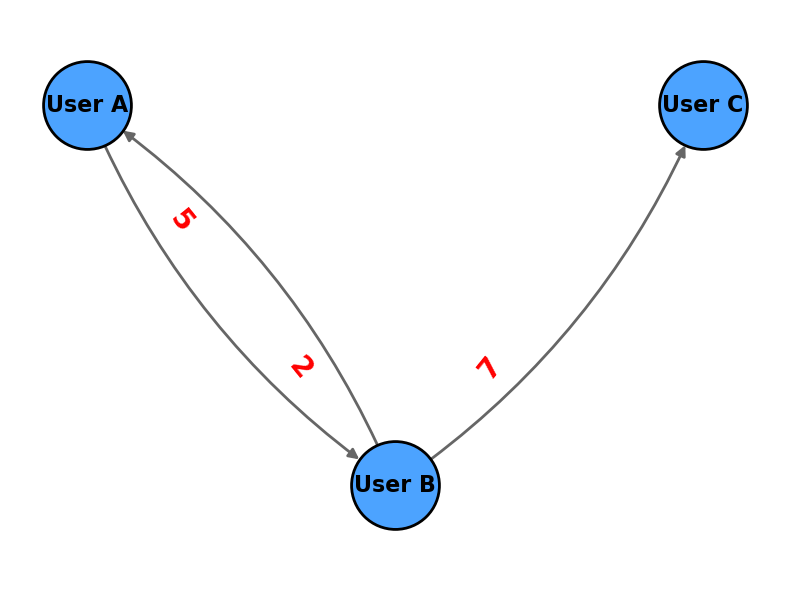

In [88]:
import networkx as nx
import matplotlib.pyplot as plt

# Initialize a Directed Graph
G = nx.DiGraph()

# Add nodes
nodes = ["User A", "User B", "User C"]
G.add_nodes_from(nodes)

# Add edges with specific numbers (weights)
# A points to B, B points to A, B points to C. C points to no one.
edges = [
    ("User A", "User B", 5),  # User A -> User B (Weight: 5)
    ("User B", "User A", 2),  # User B -> User A (Weight: 2)
    ("User B", "User C", 7)   # User B -> User C (Weight: 7)
]
G.add_weighted_edges_from(edges)

# Set up the Visualization
fig, ax = plt.subplots(figsize=(8, 6))

# Hardcode the positions into a clean triangle layout
pos = {
    "User A": (0, 1),
    "User B": (1, 0),
    "User C": (2, 1)
}

# Draw Nodes (the three circles)
nx.draw_networkx_nodes(G, pos, node_size=4000, node_color='#4ca3ff', 
                       edgecolors='black', linewidths=2)

# Draw Node Labels
nx.draw_networkx_labels(G, pos, font_size=16, font_weight='bold')

# Draw Directed Edges (Arrows)
# connectionstyle='arc3,rad=0.15' bends the arrows so mutual edges don't overlap
nx.draw_networkx_edges(G, pos, edgelist=G.edges(), width=2, 
                       arrowstyle='-|>', arrowsize=15, node_size=4000, 
                       edge_color='#666666', connectionstyle='arc3,rad=0.15')

# Draw Edge Labels (The Numbers)
edge_labels = {(u, v): d['weight'] for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=20, 
                             font_weight='bold', font_color='red', label_pos=0.3)

# Styling
# plt.title("Directed Graph: Nodes, Edges, and Weights", fontsize=16, fontweight='bold', pad=15)
ax.axis('off')
ax.set_xlim(-.25, 2.25)
ax.set_ylim(-0.25, 1.25)

plt.tight_layout()
plt.show()